In [1]:
import pandas as pd

import spacy
# Load both models
nlp_en = spacy.load("en_core_web_md")
nlp_pt = spacy.load("pt_core_news_md")
import re

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/Users/kristina/anaconda3/envs/anlp_env/lib/python3.10/site-packages/thinc/compat.py:36: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  hasattr(torch, "has_mps")
/Users/kristina/anaconda3/envs/anlp_env/lib/python3.10/site-packages/thinc/compat.py:37: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  and torch.has_mps  # type: ignore[attr-defined]


In [5]:
df_all = pd.read_csv('mwe_all_annotated.csv')

In [6]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           1170 non-null   int64 
 1   text         1170 non-null   object
 2   prediction   1170 non-null   int64 
 3   label        1170 non-null   int64 
 4   error_type   1170 non-null   object
 5   experiment   1170 non-null   object
 6   lang         1170 non-null   object
 7   mwe          1170 non-null   object
 8   mwe_pattern  1170 non-null   object
dtypes: int64(3), object(6)
memory usage: 82.4+ KB


In [7]:
df_all.head()

,id,text,prediction,label,error_type,experiment,lang,mwe,mwe_pattern
0,65423,"doomchin stabbed denise webster, 61, in a mome...",1,1,true_positive,MB3,en,mental disorder,ADJ-NOUN
1,11321,our service is 100% free for you to use and yo...,1,1,true_positive,MB3,en,panda car,NOUN-NOUN
2,4378,"prior to this, we've had missions cover during...",1,1,true_positive,MB3,en,dust storm,NOUN-NOUN
3,77378,"it is completely free to download and play, an...",1,1,true_positive,MB3,en,chain reaction,NOUN-NOUN
4,30105,i am glad to say that halifax pays no attenti...,1,1,true_positive,MB3,en,economic aid,ADJ-NOUN


## Calculate cosine similarity 

In [8]:
def clean(text):
    if pd.isna(text): return ""
    return re.sub(r'[^\w\s]', '', text.lower().strip())

In [9]:
def compute_alignment(mwe, sentence, lang):
    if pd.isna(mwe): 
        return None

    # Select lang model depending on 'lang'
    if lang == 'en':
        nlp = nlp_en
    elif lang == 'pt':
        nlp = nlp_pt
    else:
        return None

    # Apply basic cleaning
    mwe = clean(mwe)
    sentence = clean(sentence)
    # Compute vector representation
    mwe_vec = nlp(mwe).vector
    text_vec = nlp(sentence).vector

    # Compute 
    return cosine_similarity([mwe_vec], [text_vec])[0][0]

In [10]:
df_all['cos_sim'] = df_all.apply(
    lambda row: compute_alignment(row['mwe'], row['text'], row['lang']), axis=1)

In [11]:
df_all['similarity_bins'] = pd.cut(df_all['cos_sim'], bins=[0, 0.4, 0.7, 1.0], labels=['low', 'mid', 'high'])


In [12]:
df_all['cos_sim'].describe()

count    1170.000000
mean        0.404468
std         0.165953
min        -0.022490
25%         0.293802
50%         0.427457
75%         0.518307
max         0.763650
Name: cos_sim, dtype: float64

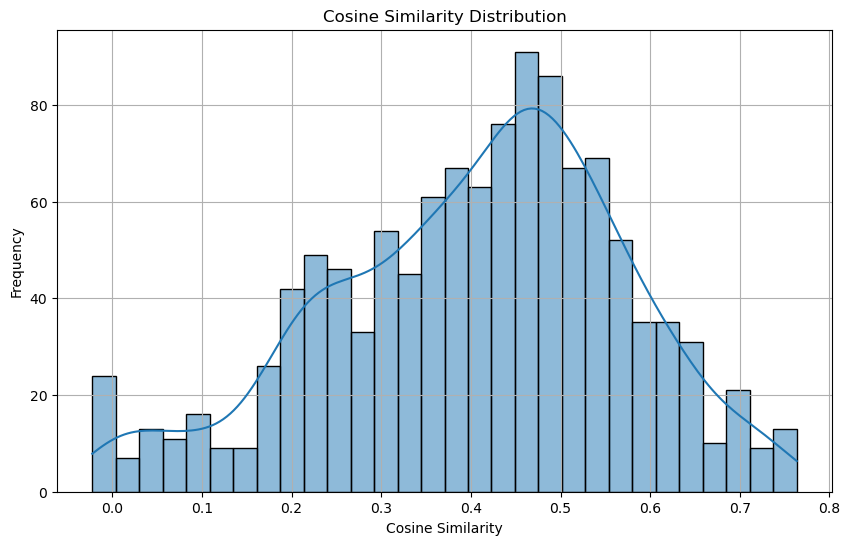

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df_all['cos_sim'].dropna(), bins=30, kde=True)
plt.title('Cosine Similarity Distribution')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.grid(True)
plt.savefig("cosine_similarity_distribution.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("cosine_similarity_distribution.png", format="png", dpi=300, bbox_inches="tight")
plt.show()

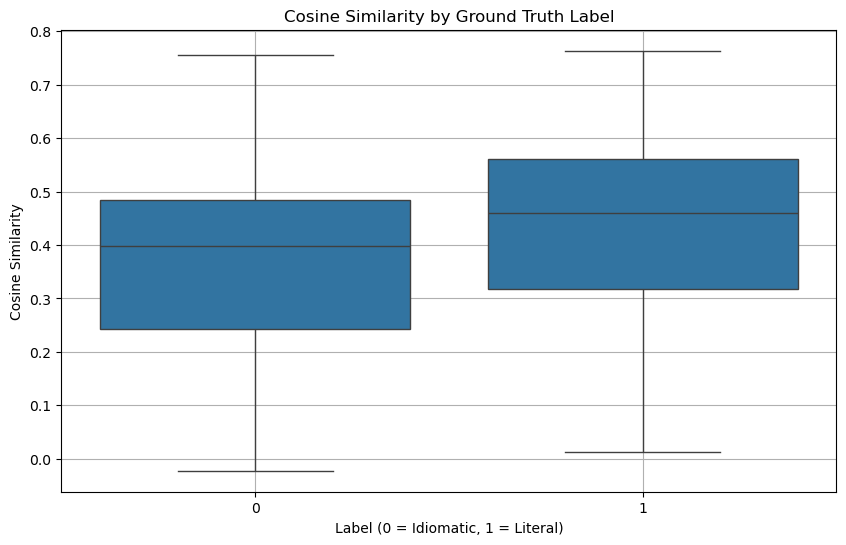

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all, x='label', y='cos_sim')
plt.title('Cosine Similarity by Ground Truth Label')
plt.xlabel('Label (0 = Idiomatic, 1 = Literal)')
plt.ylabel('Cosine Similarity')
plt.grid(True)
plt.savefig("cosine_similarity_label.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("cosine_similarity_label.png", format="png", dpi=300, bbox_inches="tight")
plt.show()

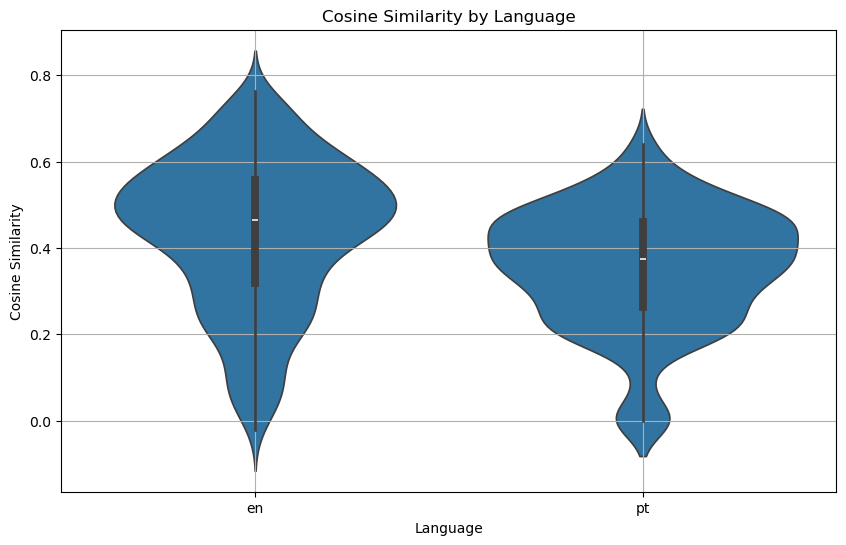

In [15]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_all, x='lang', y='cos_sim')
plt.title('Cosine Similarity by Language')
plt.xlabel('Language')
plt.ylabel('Cosine Similarity')
plt.savefig("cosine_similarity_language.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("cosine_similarity_languagge.png", format="png", dpi=300, bbox_inches="tight")
plt.grid(True)
plt.show()

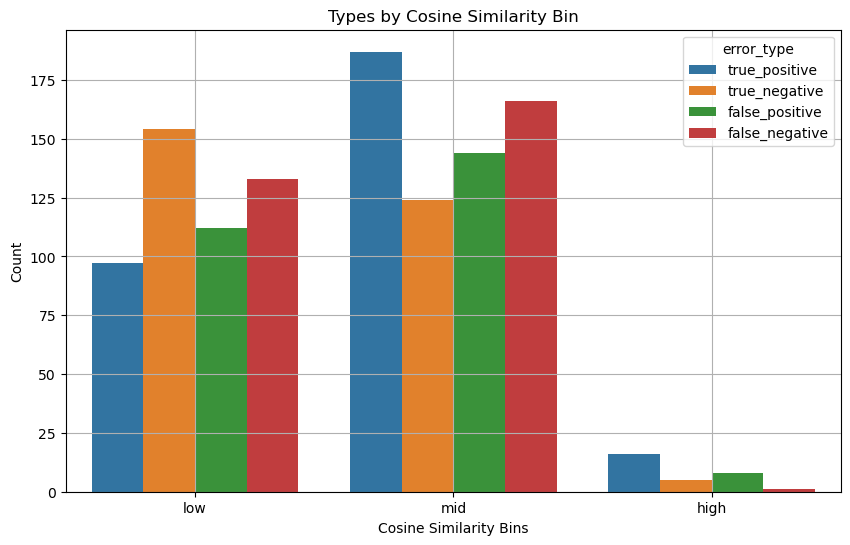

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_all, x='similarity_bins', hue='error_type')
plt.title('Types by Cosine Similarity Bin')
plt.xlabel('Cosine Similarity Bins')
plt.ylabel('Count')
plt.grid(True)
plt.savefig("cosine_similarity_type.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("cosine_similarity_type.png", format="png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
label_bin_counts = df_all.groupby(['similarity_bins', 'label']).size().reset_index(name='count')

# Map numeric labels to labels
label_bin_counts['label'] = label_bin_counts['label'].map({0: 'idiomatic', 1: 'literal'})

/var/folders/w6/grz6qnms2h16ppn2mp9bdstr0000gp/T/ipykernel_4465/4053248476.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  label_bin_counts = df_all.groupby(['similarity_bins', 'label']).size().reset_index(name='count')


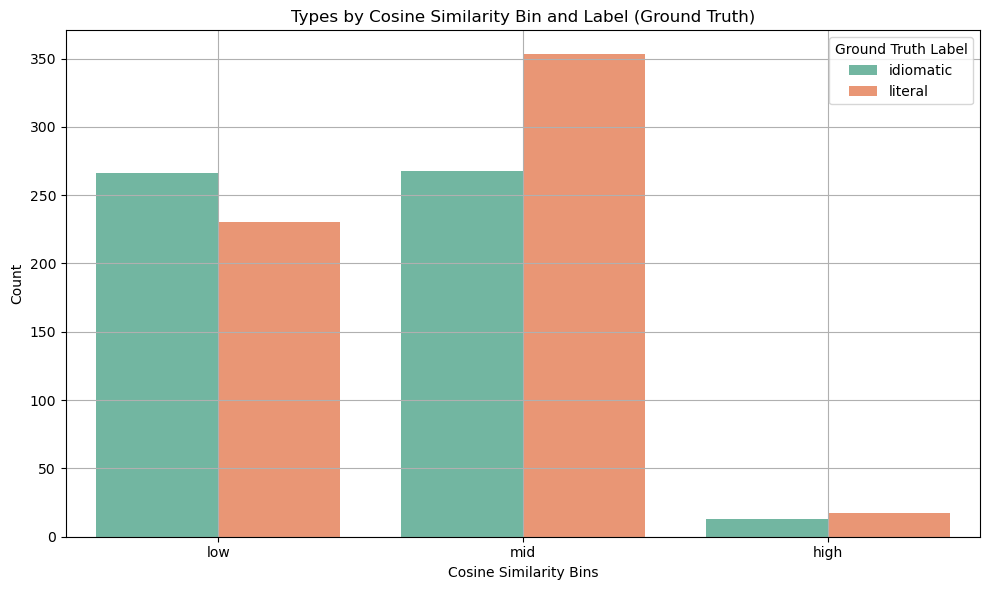

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=label_bin_counts,
    x='similarity_bins',
    y='count',
    hue='label',
    palette='Set2'
)
plt.title('Types by Cosine Similarity Bin and Label (Ground Truth)')
plt.xlabel('Cosine Similarity Bins')
plt.ylabel('Count')
plt.legend(title='Ground Truth Label')
plt.grid(True)
plt.tight_layout()
plt.savefig("cosine_similarity_type_bin.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("cosine_similarity_type_bin.png", format="png", dpi=300, bbox_inches="tight")
plt.show()

- more literal labels are in mid and high bin, cosine similarity reflects hypothesis
- most idiom labels are in low bin, also reflects hypothesis
- mid bin? overlap where further feature engineering might be necessary

In [19]:
# Top 10 lowest similarity cases
df_all.sort_values(by='cos_sim').head(10)[['text', 'mwe', 'cos_sim', 'lang']]


,text,mwe,cos_sim,lang
599,this will be the last generation of amd cpus t...,swan song,-0.022490,en
996,this will be the last generation of amd cpus t...,swan song,-0.022490,en
654,the only other team that has been given better...,swan song,-0.017736,en
1045,the only other team that has been given better...,swan song,-0.017736,en
948,vivemos um momento muito dificil e toda ajuda ...,primeira-dama,0.000000,pt
133,"a afirmaçao e da primeira-dama de cuiaba, marc...",primeira-dama,0.000000,pt
141,fico feliz em ver que a primeira-dama de chapa...,primeira-dama,0.000000,pt
150,"no último mês, os governos da armênia e do aze...",primeira-dama,0.000000,pt
888,"o carro em que a primeira-dama estava, uma sw4...",primeira-dama,0.000000,pt
193,"ela teve episódios memoráveis negativos"", cont...",primeira-dama,0.000000,pt


In [20]:
# Top 10 highest similarity
df_all.sort_values(by='cos_sim', ascending=False).head(10)[['text', 'mwe', 'cos_sim', 'lang']]

,text,mwe,cos_sim,lang
98,"for example, river stone insurance limited, a ...",insurance company,0.763650,en
267,public service is the backbone of local and st...,public service,0.755318,en
936,public service is the backbone of local and st...,public service,0.750809,en
895,the public service association welcomes the cr...,public service,0.748088,en
393,the commission that oversees maryland utilitie...,public service,0.747473,en
268,the public service association welcomes the cr...,public service,0.747153,en
262,"also, rising disposable income and changing li...",food market,0.741731,en
460,government servants who have done excellent wo...,public service,0.740919,en
171,chief minister shivraj singh chouhan will laun...,public service,0.739114,en
74,"guy carpenter & company, llc is advising prosi...",insurance company,0.738792,en


In [21]:
# clustering by MWE since repititions are present
mwe_stats = df_all.groupby('mwe')['cos_sim'].agg(
    count='count',
    mean_sim='mean',
    min_sim='min',
    max_sim='max',
    std_sim='std'
).sort_values(by='mean_sim', ascending=False)

In [22]:
# top 10
mwe_stats.head(10)

,count,mean_sim,min_sim,max_sim,std_sim
mwe,,,,,
public service,25,0.712130,0.614652,0.755318,0.031034
insurance company,19,0.679504,0.552817,0.763650,0.059818
food market,17,0.654677,0.502810,0.741731,0.063182
mental disorder,28,0.628360,0.551153,0.718361,0.047691
chain reaction,27,0.607621,0.545588,0.658061,0.033579
economic aid,17,0.602992,0.552425,0.641083,0.034009
high life,23,0.577709,0.524418,0.653879,0.034174
health check,25,0.538356,0.400521,0.683810,0.060672
travel guide,24,0.536408,0.486725,0.609653,0.031723


In [23]:
# Bottom 10
mwe_stats.tail(10)

,count,mean_sim,min_sim,max_sim,std_sim
mwe,,,,,
fila indiana,11,0.250930,0.169984,0.326550,0.054518
fio condutor,28,0.242639,0.172896,0.371127,0.052900
pastor alemão,18,0.236897,0.088226,0.360702,0.092691
bode expiatório,22,0.222640,0.169335,0.343327,0.054249
bad hat,18,0.216073,0.027224,0.339198,0.097728
bow tie,30,0.162972,0.013173,0.275212,0.075145
disco voador,21,0.159508,0.007705,0.250036,0.080869
eager beaver,23,0.154039,0.057672,0.237631,0.056384
swan song,27,0.049630,-0.022490,0.131874,0.042086


## Compare Top/Bottom 10

In [24]:
# Extract top/worst 10
top_10_mwes = mwe_stats.head(10).index.tolist()
bottom_10_mwes = mwe_stats.tail(10).index.tolist()

In [25]:
# Filter for top & bottom MWE rows only
df_filtered = df_all[df_all['mwe'].isin(top_10_mwes + bottom_10_mwes)]

# Count Occurence per experiment
exp_mwe_counts = df_filtered.groupby(['experiment', 'mwe']).size().unstack(fill_value=0)

In [26]:
exp_mwe_counts.T.sort_index()

experiment,MB3,MB4,MB5
mwe,,,
bad hat,8,3,7
bode expiatório,4,10,8
bow tie,7,15,8
chain reaction,13,6,8
disco voador,8,5,8
eager beaver,5,8,10
economic aid,5,6,6
fila indiana,3,2,6
fio condutor,10,9,9


<Figure size 1200x600 with 0 Axes>

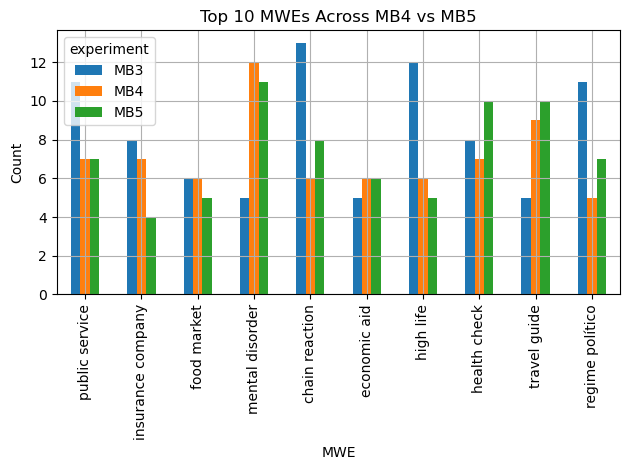

<Figure size 1200x600 with 0 Axes>

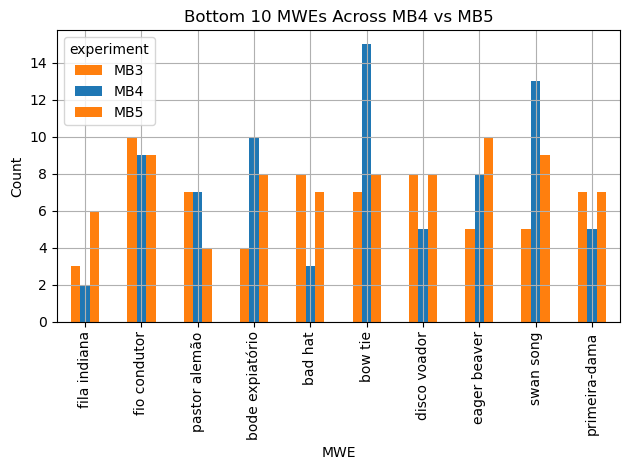

In [27]:
# Shows occurences in each experiment
# Subset barplot: Top 10 MWEs
top_counts = exp_mwe_counts[top_10_mwes].T

plt.figure(figsize=(12,6))
top_counts.plot(kind='bar')
plt.title('Top 10 MWEs Across MB4 vs MB5')
plt.xlabel('MWE')
plt.ylabel('Count')
plt.grid(True)
plt.tight_layout()
plt.show()

# Subset barplot: Bottom 10 MWEs
bottom_counts = exp_mwe_counts[bottom_10_mwes].T

plt.figure(figsize=(12,6))
bottom_counts.plot(kind='bar', color=['#ff7f0e', '#1f77b4'])  # Optional color flip
plt.title('Bottom 10 MWEs Across MB4 vs MB5')
plt.xlabel('MWE')
plt.ylabel('Count')
plt.grid(True)
plt.tight_layout()
plt.show()


In [28]:
# Get count of error_type for each mwe within each experiment
exp_mwe_errors = df_filtered.groupby(['experiment', 'mwe', 'error_type']).size().reset_index(name='count')

In [29]:
# Create pivot table: rows = MWE, cols = (experiment, error_type)
aggregate_df = exp_mwe_errors.pivot_table(
    index='mwe',
    columns=['experiment', 'error_type'],
    values='count',
    fill_value=0
)

In [30]:
aggregate_df_top = aggregate_df.loc[top_10_mwes]
aggregate_df_bottom = aggregate_df.loc[bottom_10_mwes]

In [31]:
# Reset Index
aggregate_df_top = aggregate_df_top.reset_index()
aggregate_df_bottom = aggregate_df_bottom.reset_index()

In [32]:
aggregate_df_top

experiment                mwe            MB3                               \
error_type                    false_negative false_positive true_negative   
0              public service            2.0            5.0           2.0   
1           insurance company            1.0            0.0           0.0   
2                 food market            0.0            3.0           1.0   
3             mental disorder            1.0            0.0           0.0   
4              chain reaction            1.0            7.0           0.0   
5                economic aid            2.0            0.0           0.0   
6                   high life            9.0            0.0           0.0   
7                health check            2.0            0.0           0.0   
8                travel guide            1.0            0.0           0.0   
9             regime político            9.0            0.0           0.0   

experiment                          MB4                               \
error_type true_positive false_negative false_positive true_negative   
0                    2.0            0.0            0.0           4.0   
1                    7.0            0.0            0.0           0.0   
2                    2.0            0.0            3.0           0.0   
3                    4.0            9.0            0.0           0.0   
4                    5.0            1.0            0.0           3.0   
5                    3.0            2.0            0.0           0.0   
6                    3.0            0.0            0.0           0.0   
7                    6.0            3.0            0.0           0.0   
8                    4.0            1.0            0.0           0.0   
9                    2.0            0.0            0.0           0.0   

experiment                          MB5                               \
error_type true_positive false_negative false_positive true_negative   
0                    3.0            0.0            1.0           3.0   
1                    7.0            1.0            0.0           0.0   
2                    3.0            0.0            2.0           0.0   
3                    3.0           10.0            0.0           0.0   
4                    2.0            2.0            1.0           2.0   
5                    4.0            2.0            0.0           0.0   
6                    6.0            1.0            0.0           0.0   
7                    4.0            0.0            0.0           0.0   
8                    8.0            3.0            0.0           0.0   
9                    5.0            0.0            0.0           0.0   

experiment                
error_type true_positive  
0                    3.0  
1                    3.0  
2                    3.0  
3                    1.0  
4                    3.0  
5                    4.0  
6                    4.0  
7                   10.0  
8                    7.0  
9                    7.0

In [33]:
aggregate_df_bottom

experiment              mwe            MB3                               \
error_type                  false_negative false_positive true_negative   
0              fila indiana            0.0            0.0           3.0   
1              fio condutor            3.0            1.0           5.0   
2             pastor alemão            0.0            5.0           2.0   
3           bode expiatório            0.0            2.0           2.0   
4                   bad hat            4.0            0.0           3.0   
5                   bow tie            2.0            0.0           0.0   
6              disco voador            1.0            0.0           7.0   
7              eager beaver            0.0            0.0           4.0   
8                 swan song            0.0            1.0           4.0   
9             primeira-dama            0.0            2.0           5.0   

experiment                          MB4                               \
error_type true_positive false_negative false_positive true_negative   
0                    0.0            0.0            0.0           2.0   
1                    1.0            1.0            5.0           2.0   
2                    0.0            0.0            7.0           0.0   
3                    0.0            0.0            2.0           8.0   
4                    1.0            1.0            0.0           1.0   
5                    5.0            8.0            0.0           0.0   
6                    0.0            1.0            0.0           4.0   
7                    1.0            0.0            8.0           0.0   
8                    0.0            0.0           12.0           0.0   
9                    0.0            0.0            0.0           5.0   

experiment                          MB5                               \
error_type true_positive false_negative false_positive true_negative   
0                    0.0            0.0            6.0           0.0   
1                    1.0            0.0            8.0           0.0   
2                    0.0            0.0            2.0           2.0   
3                    0.0            0.0            2.0           6.0   
4                    1.0            3.0            1.0           2.0   
5                    7.0            2.0            0.0           0.0   
6                    0.0            0.0            1.0           6.0   
7                    0.0            0.0            9.0           0.0   
8                    1.0            0.0            6.0           1.0   
9                    0.0            0.0            0.0           7.0   

experiment                
error_type true_positive  
0                    0.0  
1                    1.0  
2                    0.0  
3                    0.0  
4                    1.0  
5                    6.0  
6                    1.0  
7                    1.0  
8                    2.0  
9                    0.0